# Корпуса: blending классики и MLP

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)

Проверяю два варианта весов:

1. `equal-weight soft voting` -- обычное среднее probabilities;
2. `metric-weighted` -- численные веса пропорциональны train-CV balanced accuracy, а не напрямую качеству на hold-out validation.

В blending беру сильные и достаточно разные модели: `Logistic Regression`, `Random Forest` и `MLP`. Слабый `GaussianNB` не добавляю.

Все probabilities относятся к одному и тому же hold-out validation split, потому что в [01_MLP_architecture.ipynb](/notebooks/01_MLP_architecture.ipynb) и [02_classical_models.ipynb](/notebooks/02_classical_models.ipynb) используются одинаковые `SEED`, `VAL_SIZE` и исходный порядок объектов.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


cwd = Path.cwd().resolve()
if (cwd / "hws").exists():
    HWS_DIR = cwd / "hws"
elif cwd.name == "notebooks":
    HWS_DIR = cwd.parent
elif (cwd / "notebooks").exists() and (cwd / "report").exists():
    HWS_DIR = cwd
else:
    HWS_DIR = cwd

OUTPUT_DIR = HWS_DIR / "output"
sns.set_theme(style="whitegrid")


## Почему blend может ничего не улучшить

Это нормально: averaging не гарантирует прирост. Если сильные модели делают очень похожие вероятностные прогнозы и ошибки, усреднять по сути нечего. А если одна из моделей слабее, equal-weight blend может даже ухудшить лучший одиночный алгоритм.  
_Неоднократно с таким сталкивался на практике._

Поэтому ниже сначала смотрю **корреляции probabilities и ошибок**, затем численные метрики, и только после этого интерпретирую результат blend.

In [20]:
def load_probs(path):
    data = np.load(path)
    return data["y_true"], data["probabilities"]


def metrics(y_true, probabilities):
    y_pred = probabilities.argmax(axis=1)
    return {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "y_pred": y_pred,
    }


def cv_scores(dataset_name, slug):
    classical = pd.read_csv(OUTPUT_DIR / f"{slug}_classical_results.csv")
    scores = dict(zip(classical.model, classical.cv_balanced_accuracy))

    mlp_cv = pd.read_csv(OUTPUT_DIR / "mlp_cv_results.csv")
    scores["MLP"] = mlp_cv[
        mlp_cv.dataset == dataset_name
    ].balanced_accuracy.mean()
    return scores


def normalized_metric_weights(model_names, scores):
    raw = np.array([scores[name] for name in model_names], dtype=float)
    return raw / raw.sum()


def weighted_probabilities(loaded, names, weights):
    stacked = np.stack([loaded[name][1] for name in names])
    return np.tensordot(weights, stacked, axes=(0, 0))


def correlation_tables(loaded):
    probability_corr = pd.DataFrame({
        name: probabilities.ravel()
        for name, (_, probabilities) in loaded.items()
    }).corr()

    errors = {}
    for name, (y_true, probabilities) in loaded.items():
        errors[name] = (probabilities.argmax(axis=1) != y_true).astype(float)
    error_corr = pd.DataFrame(errors).corr()

    return probability_corr, error_corr


def run_blends(dataset_name, slug):
    model_files = {
        "Logistic Regression": OUTPUT_DIR / f"{slug}_logistic_regression_validation_predictions.npz",
        "Random Forest": OUTPUT_DIR / f"{slug}_random_forest_validation_predictions.npz",
        "MLP": OUTPUT_DIR / f"{slug}_mlp_validation_predictions.npz",
    }
    model_files = {
        name: path for name, path in model_files.items() if path.exists()
    }

    loaded = {name: load_probs(path) for name, path in model_files.items()}
    y_true = loaded["MLP"][0]

    for name, (candidate_y, _) in loaded.items():
        if not np.array_equal(candidate_y, y_true):
            raise ValueError(f"Validation order mismatch for {name}")

    rows = []
    for name, (_, probabilities) in loaded.items():
        row = metrics(y_true, probabilities)
        row.update({"dataset": dataset_name, "model": name, "blend_type": "single"})
        rows.append(row)

    classical_names = [name for name in loaded if name != "MLP"]
    all_names = list(loaded)

    equal_classical = np.mean([loaded[name][1] for name in classical_names], axis=0)
    equal_all = np.mean([loaded[name][1] for name in all_names], axis=0)

    scores = cv_scores(dataset_name, slug)
    classical_weights = normalized_metric_weights(classical_names, scores)
    all_weights = normalized_metric_weights(all_names, scores)
    metric_classical = weighted_probabilities(loaded, classical_names, classical_weights)
    metric_all = weighted_probabilities(loaded, all_names, all_weights)

    blends = [
        ("Blend: classical equal", "equal", equal_classical),
        ("Blend: all equal", "equal", equal_all),
        ("Blend: classical metric-weighted", "metric", metric_classical),
        ("Blend: all metric-weighted", "metric", metric_all),
    ]

    for name, blend_type, probabilities in blends:
        row = metrics(y_true, probabilities)
        row.update({"dataset": dataset_name, "model": name, "blend_type": blend_type})
        rows.append(row)

    weight_rows = []
    for group, names, weights in [
        ("classical", classical_names, classical_weights),
        ("all", all_names, all_weights),
    ]:
        for name, weight in zip(names, weights):
            weight_rows.append({
                "dataset": dataset_name,
                "blend": group,
                "model": name,
                "cv_balanced_accuracy": scores[name],
                "weight": weight,
            })

    probability_corr, error_corr = correlation_tables(loaded)
    result = pd.DataFrame(rows)[[
        "dataset", "model", "blend_type", "balanced_accuracy",
        "macro_f1", "macro_precision", "macro_recall", "y_pred",
    ]]
    return result, y_true, probability_corr, error_corr, pd.DataFrame(weight_rows)

In [21]:
mnist_blending, mnist_y, mnist_probability_corr, mnist_error_corr, mnist_weights = run_blends(
    "MNIST", "mnist"
)
fashion_blending, fashion_y, fashion_probability_corr, fashion_error_corr, fashion_weights = run_blends(
    "Fashion-MNIST", "fashion"
)

blending_results = pd.concat([mnist_blending, fashion_blending], ignore_index=True)
blending_weights = pd.concat([mnist_weights, fashion_weights], ignore_index=True)

blending_results.drop(columns="y_pred").to_csv(
    OUTPUT_DIR / "blending_results.csv", index=False
)
blending_weights.to_csv(OUTPUT_DIR / "blending_weights.csv", index=False)

blending_results.drop(columns="y_pred").sort_values(
    ["dataset", "balanced_accuracy"], ascending=[True, False]
)

,dataset,model,blend_type,balanced_accuracy,macro_f1,macro_precision,macro_recall
11,Fashion-MNIST,Blend: all equal,equal,0.881600,0.881414,0.881981,0.881600
13,Fashion-MNIST,Blend: all metric-weighted,metric,0.881600,0.881394,0.881969,0.881600
9,Fashion-MNIST,MLP,single,0.874600,0.875140,0.878340,0.874600
8,Fashion-MNIST,Random Forest,single,0.873500,0.872230,0.872515,0.873500
12,Fashion-MNIST,Blend: classical metric-weighted,metric,0.866000,0.865061,0.864847,0.866000
10,Fashion-MNIST,Blend: classical equal,equal,0.865600,0.864678,0.864464,0.865600
7,Fashion-MNIST,Logistic Regression,single,0.846700,0.846463,0.846504,0.846700
2,MNIST,MLP,single,0.967218,0.967059,0.967261,0.967218
6,MNIST,Blend: all metric-weighted,metric,0.967056,0.966969,0.966973,0.967056
4,MNIST,Blend: all equal,equal,0.966745,0.966674,0.966686,0.966745


## Корреляции predictions

`probability correlation` считаю по развернутым матрицам вероятностей `n_objects × n_classes`.

Дополнительно считаю корреляцию бинарных индикаторов ошибки. Высокая корреляция в обеих таблицах означает, что модели часто уверены в одном и том же и ошибаются на одних и тех же объектах -- тогда большого выигрыша от blending ждать не стоит.

,Logistic Regression,Random Forest,MLP
Logistic Regression,1.000,0.947,0.933
Random Forest,0.947,1.000,0.947
MLP,0.933,0.947,1.000


,Logistic Regression,Random Forest,MLP
Logistic Regression,1.000,0.509,0.391
Random Forest,0.509,1.000,0.507
MLP,0.391,0.507,1.000


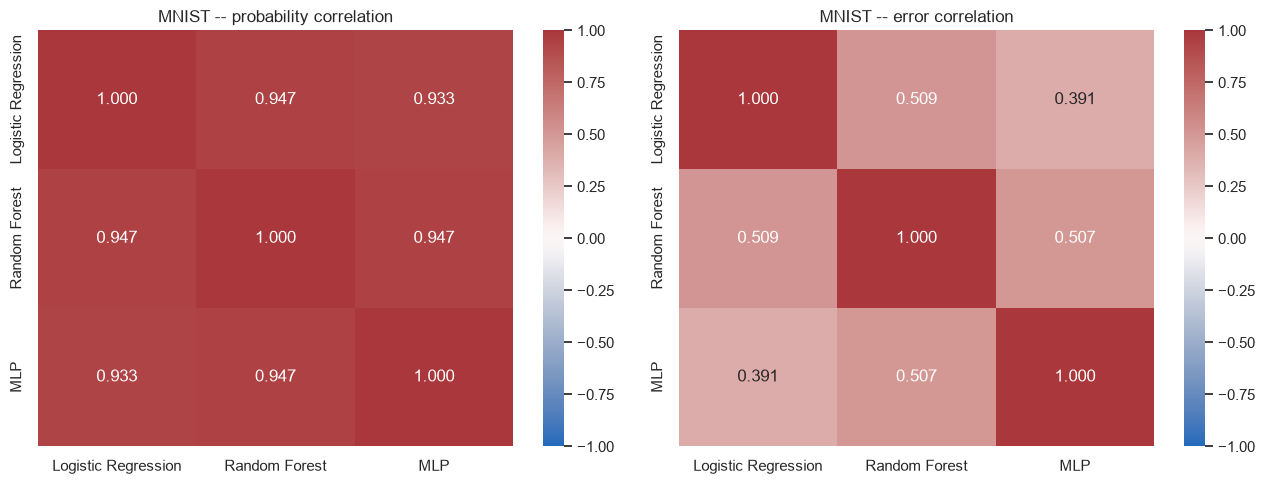

,Logistic Regression,Random Forest,MLP
Logistic Regression,1.000,0.937,0.940
Random Forest,0.937,1.000,0.946
MLP,0.940,0.946,1.000


,Logistic Regression,Random Forest,MLP
Logistic Regression,1.000,0.555,0.589
Random Forest,0.555,1.000,0.555
MLP,0.589,0.555,1.000


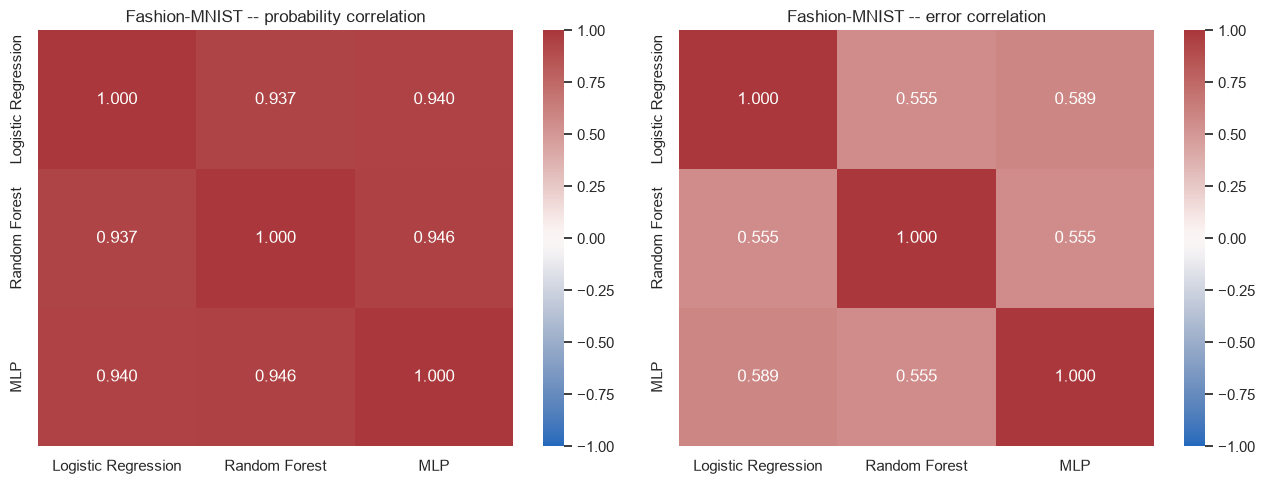

In [22]:
def plot_correlations(probability_corr, error_corr, dataset_name, slug):
    display(probability_corr.round(3))
    display(error_corr.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(
        probability_corr,
        annot=True,
        fmt=".3f",
        cmap="vlag",
        vmin=-1,
        vmax=1,
        ax=axes[0],
    )
    axes[0].set_title(f"{dataset_name} -- probability correlation")

    sns.heatmap(
        error_corr,
        annot=True,
        fmt=".3f",
        cmap="vlag",
        vmin=-1,
        vmax=1,
        ax=axes[1],
    )
    axes[1].set_title(f"{dataset_name} -- error correlation")

    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"{slug}_prediction_correlations.png",
        dpi=170,
        bbox_inches="tight",
    )
    plt.show()

    probability_corr.to_csv(OUTPUT_DIR / f"{slug}_probability_correlation.csv")
    error_corr.to_csv(OUTPUT_DIR / f"{slug}_error_correlation.csv")


plot_correlations(
    mnist_probability_corr, mnist_error_corr, "MNIST", "mnist"
)
plot_correlations(
    fashion_probability_corr, fashion_error_corr, "Fashion-MNIST", "fashion"
)

Почти уверен, что прироста не будет.

## Численные метрики и веса metric-based blend

График удобен для обзора, но небольшие различия на нем почти не видны. Поэтому отдельно вывожу численную таблицу всех метрик и веса, рассчитанные из train-CV.

Важно: **веса не подбираются по hold-out validation**. Но сами blend-метрики трактую как exploratory, потому что MLP-архитектура раньше уже выбиралась по этому validation. Финальной независимой оценкой остается official test из `01`.

In [23]:
display(
    blending_results.drop(columns="y_pred").sort_values(
        ["dataset", "balanced_accuracy"], ascending=[True, False]
    ).reset_index(drop=True)
)

display(
    blending_weights.sort_values(["dataset", "blend", "weight"], ascending=[True, True, False])
    .reset_index(drop=True)
)

,dataset,model,blend_type,balanced_accuracy,macro_f1,macro_precision,macro_recall
0,Fashion-MNIST,Blend: all equal,equal,0.881600,0.881414,0.881981,0.881600
1,Fashion-MNIST,Blend: all metric-weighted,metric,0.881600,0.881394,0.881969,0.881600
2,Fashion-MNIST,MLP,single,0.874600,0.875140,0.878340,0.874600
3,Fashion-MNIST,Random Forest,single,0.873500,0.872230,0.872515,0.873500
4,Fashion-MNIST,Blend: classical metric-weighted,metric,0.866000,0.865061,0.864847,0.866000
5,Fashion-MNIST,Blend: classical equal,equal,0.865600,0.864678,0.864464,0.865600
6,Fashion-MNIST,Logistic Regression,single,0.846700,0.846463,0.846504,0.846700
7,MNIST,MLP,single,0.967218,0.967059,0.967261,0.967218
8,MNIST,Blend: all metric-weighted,metric,0.967056,0.966969,0.966973,0.967056
9,MNIST,Blend: all equal,equal,0.966745,0.966674,0.966686,0.966745


,dataset,blend,model,cv_balanced_accuracy,weight
0,Fashion-MNIST,all,Random Forest,0.873200,0.340389
1,Fashion-MNIST,all,MLP,0.849150,0.331014
2,Fashion-MNIST,all,Logistic Regression,0.842950,0.328597
3,Fashion-MNIST,classical,Random Forest,0.873200,0.508813
4,Fashion-MNIST,classical,Logistic Regression,0.842950,0.491187
5,MNIST,all,Random Forest,0.956962,0.339541
6,MNIST,all,MLP,0.955547,0.339039
7,MNIST,all,Logistic Regression,0.905889,0.321420
8,MNIST,classical,Random Forest,0.956962,0.513708
9,MNIST,classical,Logistic Regression,0.905889,0.486292


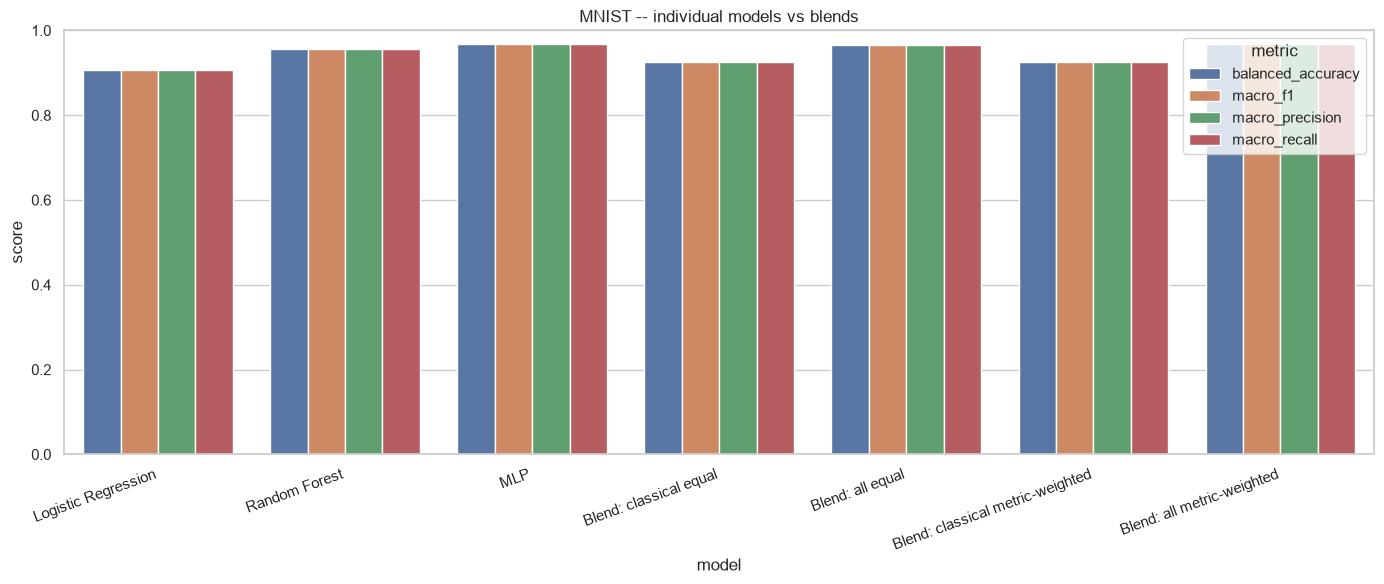

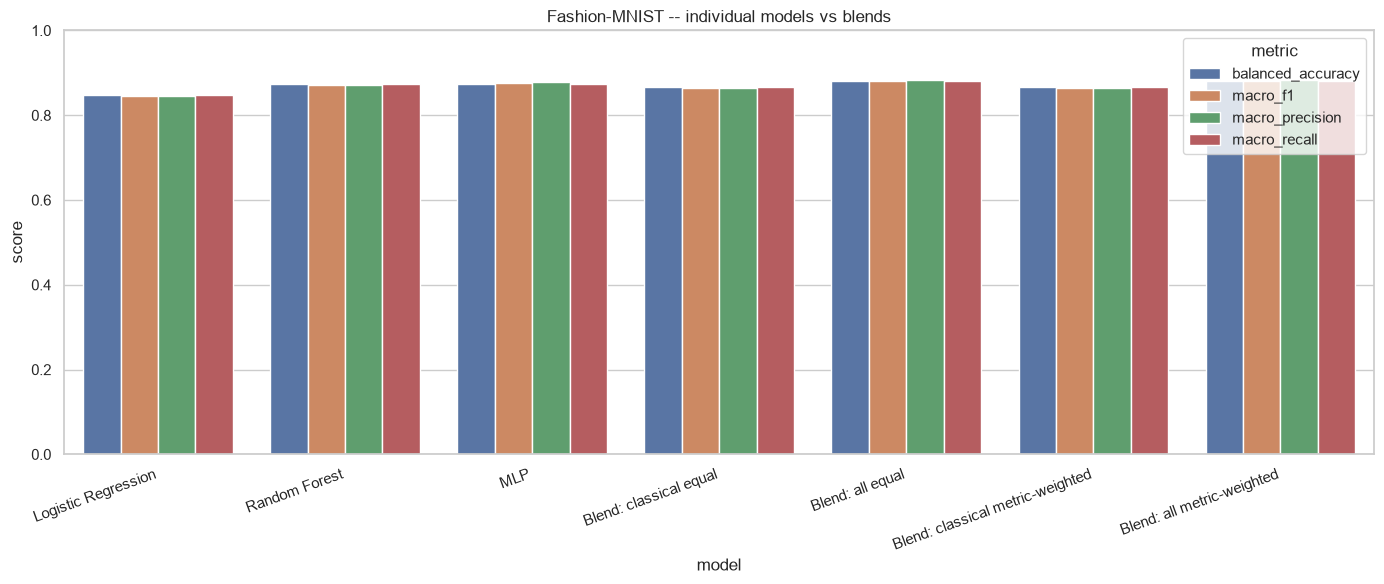

In [24]:
plot_data = blending_results.drop(columns="y_pred").melt(
    id_vars=["dataset", "model", "blend_type"],
    value_vars=["balanced_accuracy", "macro_f1", "macro_precision", "macro_recall"],
    var_name="metric",
    value_name="score",
)

for dataset_name in ["MNIST", "Fashion-MNIST"]:
    plt.figure(figsize=(14, 6))
    sns.barplot(
        data=plot_data[plot_data.dataset == dataset_name],
        x="model",
        y="score",
        hue="metric",
    )
    plt.ylim(0, 1)
    plt.title(f"{dataset_name} -- individual models vs blends")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    slug = dataset_name.lower().replace("-", "_")
    plt.savefig(
        OUTPUT_DIR / f"{slug}_blending_metrics.png",
        dpi=170,
        bbox_inches="tight",
    )
    plt.show()

In [25]:
def plot_best_blend(result, y_true, class_names, slug):
    best = result.sort_values("balanced_accuracy", ascending=False).iloc[0]
    cm = confusion_matrix(y_true, best.y_pred, normalize="true")
    plt.figure(figsize=(11, 9))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names, annot_kws={"size":8}, vmin=0, vmax=1)
    plt.title(f"{slug} -- {best.model}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{slug}_best_blend_confusion_matrix.png", dpi=180, bbox_inches="tight")
    plt.show()


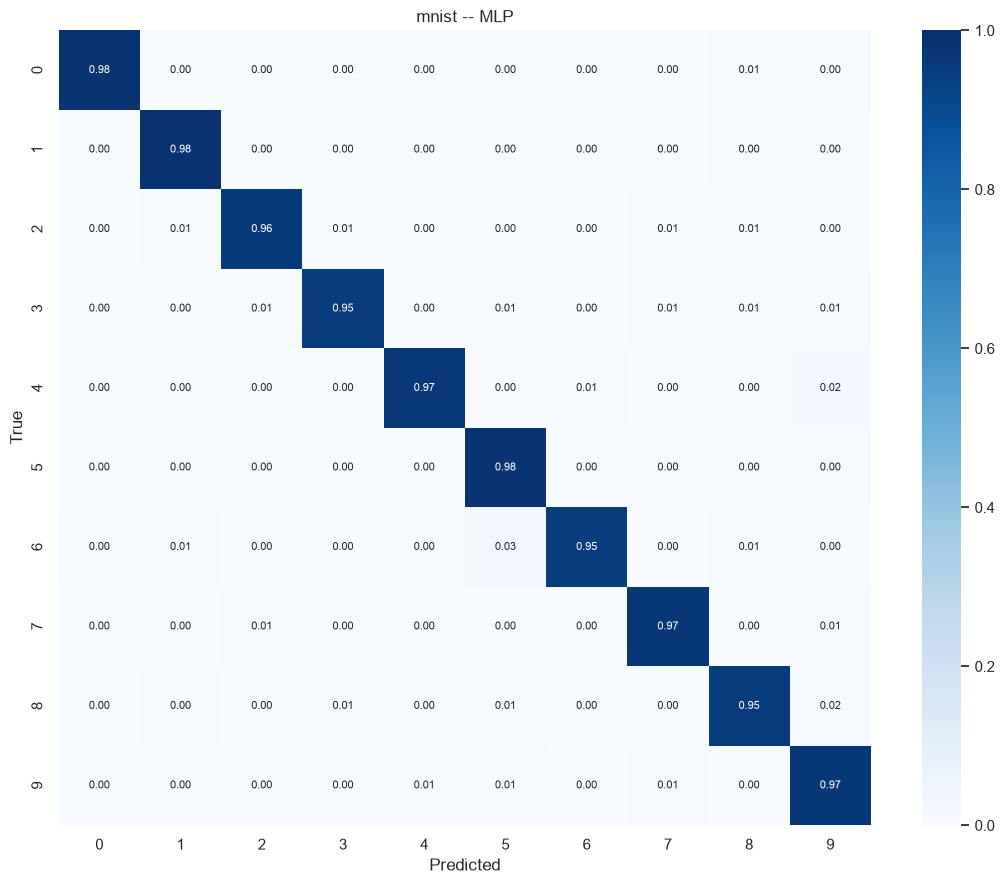

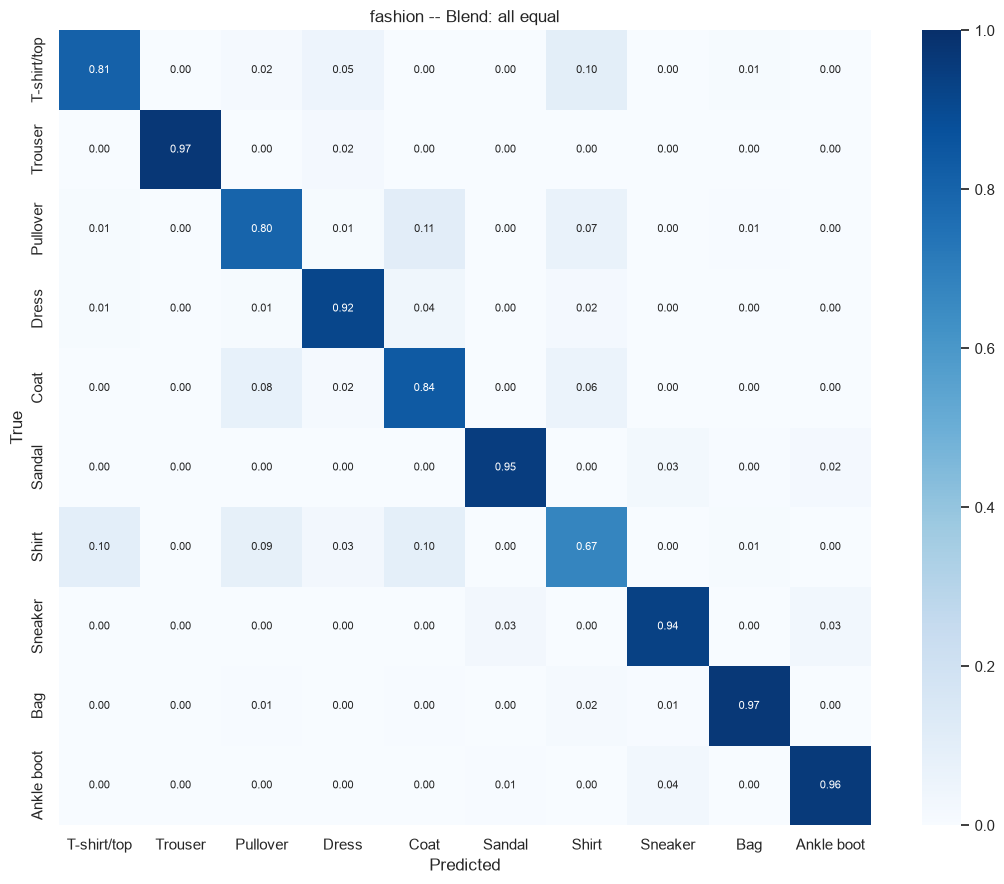

In [26]:
plot_best_blend(mnist_blending, mnist_y, [str(i) for i in range(10)], "mnist")
plot_best_blend(
    fashion_blending,
    fashion_y,
    ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"],
    "fashion",
)

Для чисел лучшей моделью оказалась `MLP`, для `Fashion` -- equal-blend.

## Обновление численных результатов для отчета

In [27]:
required = [
    OUTPUT_DIR / "mlp_final_results.csv",
    OUTPUT_DIR / "mlp_cv_results.csv",
    OUTPUT_DIR / "model_comparison.csv",
    OUTPUT_DIR / "blending_results.csv",
    OUTPUT_DIR / "synthetic_grid_results.csv",
]

if all(path.exists() for path in required):
    final_mlp = pd.read_csv(OUTPUT_DIR / "mlp_final_results.csv")
    mlp_cv = pd.read_csv(OUTPUT_DIR / "mlp_cv_results.csv")
    comparison = pd.read_csv(OUTPUT_DIR / "model_comparison.csv")
    blends = pd.read_csv(OUTPUT_DIR / "blending_results.csv")
    synthetic = pd.read_csv(OUTPUT_DIR / "synthetic_grid_results.csv")

    if synthetic["function"].nunique() < 4:
        print("Сначала перезапустите 03_synthetic_mlp_approximation.ipynb: нужны heatmap для всех функций.")
    else:
        lines = [r"\section*{Численные результаты после полного запуска}"]

        for dataset in ["MNIST", "Fashion-MNIST"]:
            final = final_mlp[final_mlp.dataset == dataset].iloc[0]
            cv_part = mlp_cv[mlp_cv.dataset == dataset]
            best_validation = comparison[comparison.dataset == dataset].sort_values(
                "balanced_accuracy", ascending=False
            ).iloc[0]
            best_blend = blends[blends.dataset == dataset].sort_values(
                "balanced_accuracy", ascending=False
            ).iloc[0]

            lines.append(
                rf"\textbf{{{dataset}}}: final MLP test balanced accuracy = {final.test_balanced_accuracy:.4f}, "
                rf"macro-F1 = {final.test_macro_f1:.4f}; 5-fold CV = "
                rf"{cv_part.balanced_accuracy.mean():.4f} $\pm$ {cv_part.balanced_accuracy.std():.4f}; "
                rf"лучшая validation model = {best_validation['model']} ({best_validation.balanced_accuracy:.4f}); "
                rf"лучший blend = {best_blend['model']} ({best_blend.balanced_accuracy:.4f}).\par"
            )

        for function_name in synthetic["function"].unique():
            best_syn = synthetic[synthetic.function == function_name].sort_values("test_mse").iloc[0]
            lines.append(
                rf"{function_name}: best depth={int(best_syn.depth)}, width={int(best_syn.width)}, "
                rf"MSE={best_syn.test_mse:.6f}.\par"
            )

        (OUTPUT_DIR / "generated_results.tex").write_text(
            "\n".join(lines), encoding="utf-8"
        )
        print("output/generated_results.tex updated")
else:
    print("Для generated_results.tex сначала выполните ноутбуки 01--04 по порядку.")

output/generated_results.tex updated


## Выводы

- таблицы probability/error correlation позволяют заранее понять, что числа уже не спасти;
- метрику на `Fashion` помог улучшить равномерный бленд (взвешенный дал такую же `balanced accuracy`);
- кроме equal weights добавлен metric-based blend, где численные веса вычисляются из train-CV balanced accuracy.